## Feature Construction and Dataset Assembly (RDKit-based)

### Purpose
This cell constructs a unified molecular feature matrix from multiple reaction datasets.  
Each sample (reaction) is represented by **three molecular components**—`dioxazolone`, `OH`, and `product`—and each component is encoded using a **fixed, reproducible RDKit feature block**.  
All datasets are concatenated into a single embedding space, enabling direct comparison and joint visualization (e.g., t-SNE).

---

### Overview of the Workflow

1. **Import scientific and cheminformatics libraries**
   - NumPy / Pandas for data handling
   - RDKit for SMILES parsing and molecular featurization
   - Matplotlib / Seaborn for downstream visualization

2. **Define robust SMILES parsing**
   - Safely converts SMILES strings to RDKit `Mol` objects
   - Handles empty or invalid entries gracefully

3. **Define molecular feature blocks**
   Each molecule is encoded as the concatenation of:
   - RDKit physicochemical descriptors (`rdMolDescriptors.Properties`)
   - Morgan fingerprint bits (ECFP-style, radius=2, 2048 bits)
   - MACCS keys (167 bits)

4. **Load and label datasets**
   Four CSV datasets are loaded and assigned semantic labels:
   - `modeling`
   - `component-disjoint`
   - `class-shift`
   - `prospective`

5. **Concatenate datasets**
   All datasets are merged into a single table (`df_all`) to ensure a shared feature and embedding space.

6. **Validate required SMILES columns**
   Ensures that all expected molecular columns (`dioxazolone`, `OH`, `product`) are present before featurization.

7. **Handle invalid SMILES consistently**
   Two strategies are supported:
   - `"drop"`: remove any row where *any* of the three molecules is invalid
   - `"zeros"`: keep rows and substitute zero vectors for invalid molecules  
   (This script uses `"drop"` for strict chemical validity.)

8. **Build the final feature matrix**
   - Each SMILES column is featurized independently
   - Feature blocks for the three molecules are horizontally concatenated
   - The final matrix has shape:
     ```
     (n_samples, 3 × (n_props + 2048 + 167))
     ```

9. **Extract dataset labels**
   A parallel `labels` array is retained for coloring or stratifying samples in downstream analyses.

---

### Outputs

- `X`  
  A NumPy array containing concatenated molecular features for all valid samples.

- `labels`  
  A 1D array indicating the dataset origin of each sample (`modeling`, `component-disjoint`, etc.).

---

### Design Notes

- Feature definitions are **fully deterministic and RDKit-native**, ensuring reproducibility.
- All molecules are embedded into a **single joint feature space**, which is critical for meaningful cross-split visualization.
- Invalid SMILES handling is explicit and centralized to avoid silent misalignment bugs.
- This cell performs **feature construction only**; no scaling, embedding, or plotting is done here.

---


In [1]:
import numpy as np
import pandas as pd

from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem, MACCSkeys
from rdkit.Chem import rdMolDescriptors

import seaborn as sns
import matplotlib.pyplot as plt

def mol_from_smiles(s):
    if pd.isna(s):
        return None
    s = str(s).strip()
    if not s:
        return None
    return Chem.MolFromSmiles(s)

def rdkit_props(mol):
    return np.asarray(list(prop_calc.ComputeProperties(mol)), dtype=np.float32)

def morgan_bits(mol, n_bits=2048, radius=2):
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=n_bits)
    arr = np.zeros((n_bits,), dtype=np.float32)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

def maccs_bits(mol):
    fp = MACCSkeys.GenMACCSKeys(mol)  # 167 bits
    arr = np.zeros((fp.GetNumBits(),), dtype=np.float32)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

def featurize_series(series, prefix, n_bits=2048, radius=2, invalid="drop"):
    feats = []
    ok = []
    for s in series:
        mol = mol_from_smiles(s)
        if mol is None:
            if invalid == "zeros":
                feats.append(np.zeros((n_props + n_bits + 167,), dtype=np.float32))
                ok.append(True)
            else:
                ok.append(False)
            continue

        vec = np.concatenate([
            rdkit_props(mol),
            morgan_bits(mol, n_bits=n_bits, radius=radius),
            maccs_bits(mol),
        ]).astype(np.float32)

        feats.append(vec)
        ok.append(True)

    feats = np.vstack(feats) if len(feats) else np.zeros((0, n_props + n_bits + 167), dtype=np.float32)
    return feats, np.asarray(ok, dtype=bool)

# ---- 1) Load datasets (EXACTLY as original app.py semantics) ----
df_model = pd.read_csv("dataset/Model_480.csv")
df_ind   = pd.read_csv("dataset/StrictIndependent_180.csv")
df_ext   = pd.read_csv("dataset/External_8.csv")
df_pro   = pd.read_csv("dataset/Alcohol_96.csv")

df_model["set"] = "modeling"
df_ind["set"]   = "component-disjoint"
df_pro["set"]   = "class-shift"
df_ext["set"]   = "prospective"

# ---- 2) Concatenate (single embedding space) ----
df_all = pd.concat([df_model, df_ind, df_ext, df_pro], axis=0, ignore_index=True)

# Optional: strip column name whitespace just in case
df_all.columns = [c.strip() for c in df_all.columns]

# ---- 3) Build features from SMILES columns ----
SMILES_COLS = ["dioxazolone", "OH", "product"]
missing = [c for c in SMILES_COLS if c not in df_all.columns]
if missing:
    raise KeyError(f"Missing SMILES columns in CSVs: {missing}. "
                   f"Available columns: {list(df_all.columns)[:30]} ...")

# RDKit descriptor calculator (stable, reproducible set)
prop_calc = rdMolDescriptors.Properties()
prop_names = list(prop_calc.GetPropertyNames())
n_props = len(prop_names)

# Choose how to handle invalid SMILES
# - "drop": drop any row where ANY of the 3 SMILES is invalid
# - "zeros": keep row, fill invalid molecule block with zeros
INVALID_POLICY = "drop"

if INVALID_POLICY == "drop":
    # first pass to find valid rows for all three columns
    _, m0 = featurize_series(df_all[SMILES_COLS[0]], prefix=SMILES_COLS[0], invalid="drop")
    _, m1 = featurize_series(df_all[SMILES_COLS[1]], prefix=SMILES_COLS[1], invalid="drop")
    _, m2 = featurize_series(df_all[SMILES_COLS[2]], prefix=SMILES_COLS[2], invalid="drop")
    keep = m0 & m1 & m2
    df_all = df_all.loc[keep].reset_index(drop=True)

# build final X by concatenating 3 molecule blocks
blocks = []
for col in SMILES_COLS:
    feats, _ = featurize_series(df_all[col], prefix=col, invalid=("zeros" if INVALID_POLICY == "zeros" else "drop"))
    blocks.append(feats)

X = np.hstack(blocks)              # <-- (n_samples, 3*(n_props+2048+167))
labels = df_all["set"].values      # <-- for plotting


[00:28:03] DEPRECATION WARNING: please use MorganGenerator
[00:28:03] DEPRECATION WARNING: please use MorganGenerator
[00:28:03] DEPRECATION WARNING: please use MorganGenerator
[00:28:03] DEPRECATION WARNING: please use MorganGenerator
[00:28:03] DEPRECATION WARNING: please use MorganGenerator
[00:28:03] DEPRECATION WARNING: please use MorganGenerator
[00:28:03] DEPRECATION WARNING: please use MorganGenerator
[00:28:03] DEPRECATION WARNING: please use MorganGenerator
[00:28:03] DEPRECATION WARNING: please use MorganGenerator
[00:28:03] DEPRECATION WARNING: please use MorganGenerator
[00:28:03] DEPRECATION WARNING: please use MorganGenerator
[00:28:03] DEPRECATION WARNING: please use MorganGenerator
[00:28:03] DEPRECATION WARNING: please use MorganGenerator
[00:28:03] DEPRECATION WARNING: please use MorganGenerator
[00:28:03] DEPRECATION WARNING: please use MorganGenerator
[00:28:03] DEPRECATION WARNING: please use MorganGenerator
[00:28:03] DEPRECATION WARNING: please use MorganGenerat

## Feature Scaling and t-SNE Embedding

### Purpose
This cell performs **feature normalization** followed by **nonlinear dimensionality reduction** using t-SNE.  
The goal is to embed high-dimensional molecular feature vectors into a **low-dimensional continuous space** suitable for visualization and exploratory analysis, while preserving local neighborhood structure.

---

### Workflow Description

1. **Standardize the feature matrix**
   - All molecular features are scaled to zero mean and unit variance using `StandardScaler`.
   - This step is critical because:
     - RDKit descriptors, fingerprints, and MACCS keys have very different numeric ranges.
     - t-SNE relies on distance computations that are sensitive to feature scaling.

2. **Determine dataset size–aware learning rate**
   - The number of samples `n` is extracted from the standardized feature matrix.
   - A heuristic lower bound is applied to the learning rate:
     ```
     learning_rate = max(200, n / 12)
     ```
   - This helps stabilize optimization for medium-to-large datasets and avoids overly small step sizes.

3. **Initialize and run t-SNE**
   - t-SNE is configured to embed data into **3 dimensions**, enabling both 2D and 3D visualization.
   - Key hyperparameters are chosen for **global structure stability** rather than aggressive local clustering:
     - `perplexity = 50`: emphasizes broader neighborhood relationships
     - `early_exaggeration = 12`: default value to aid initial cluster separation
     - `learning_rate = 10`: fixed, conservative learning rate for stable convergence
     - `init = "pca"`: PCA-based initialization for smoother global geometry
     - `metric = "euclidean"`: consistent with standardized continuous features
     - `random_state = 42`: ensures reproducibility

4. **Compute the embedding**
   - The standardized feature matrix is transformed into a 3D embedding (`emb`).
   - Each row in `emb` corresponds directly to one sample in `Xs` and retains alignment with labels defined earlier.

---

### Outputs

- `Xs`  
  Standardized feature matrix with zero mean and unit variance.

- `emb`  
  A NumPy array of shape `(n_samples, 3)` containing the t-SNE embedding coordinates.

---

### Notes and Rationale

- Standardization is mandatory when combining heterogeneous molecular descriptors and fingerprints.
- Higher perplexity values are preferred here to reduce artificial over-fragmentation and “ball-shaped” clustering.
- PCA initialization improves reproducibility and interpretability of large, dense chemical datasets.
- This cell performs **embedding only**; visualization and coloring by dataset split are handled downstream.

---


In [3]:
from sklearn.preprocessing import StandardScaler
Xs = StandardScaler().fit_transform(X)

n = Xs.shape[0]
lr = max(200.0, n / 12.0)
from sklearn.manifold import TSNE
tsne = TSNE(
    n_components=3,
    perplexity=50,
    early_exaggeration=12,
    learning_rate=10,
    # n_iter=1000,
    init="pca",
    metric="euclidean",
    random_state=42,
)
emb = tsne.fit_transform(Xs)

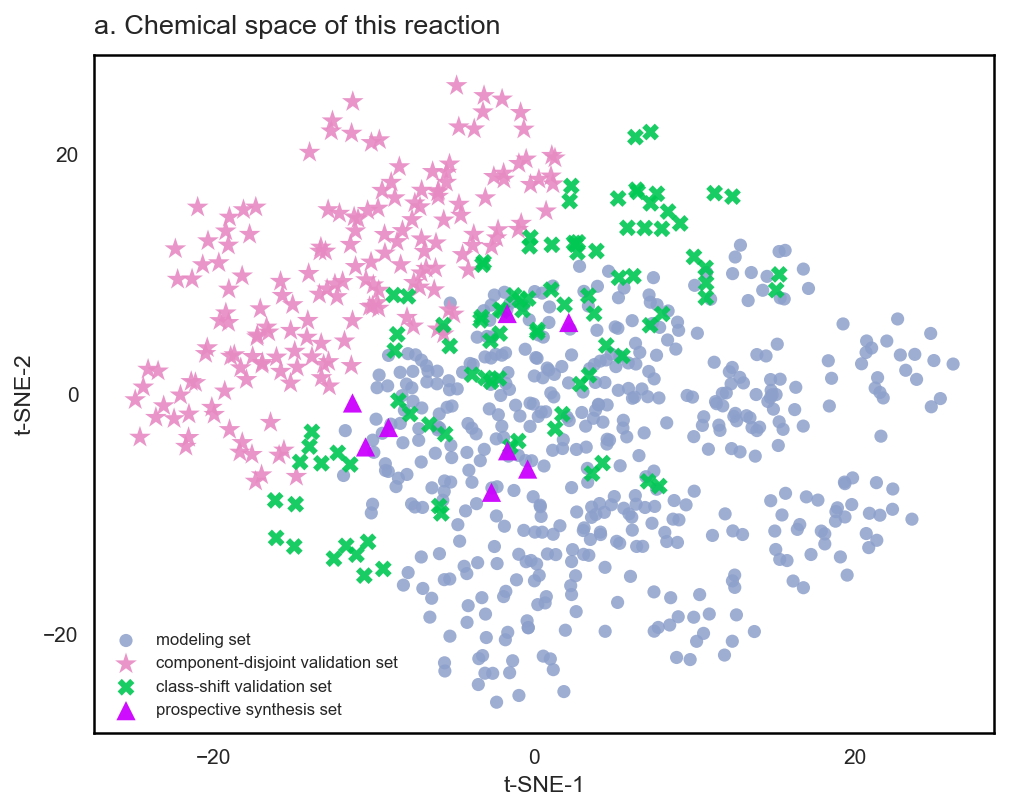

In [4]:

plot_df = pd.DataFrame({
    "x": emb[:, 0],
    "y": emb[:, 1],
    "set": labels,
})

sns.set_style("white")
sns.set_context("paper", font_scale=1.1)

fig, ax = plt.subplots(
    figsize=(6.82, 5.5),
    dpi=150
)

style_map = {
    "modeling": {
        "label": "modeling set",
        "marker": "o",
        "color": "#8da0cb",
        "size": 40,
        "alpha": 0.85,
    },
    "component-disjoint": {
        "label": "component-disjoint validation set",
        "marker": "*",
        "color": "#e78ac3",
        "size": 120,
        "alpha": 0.9,
    },
    "class-shift": {
        "label": "class-shift validation set",
        "marker": "X",
        "color": "#00c853",
        "size": 65,
        "alpha": 0.9,
    },
    "prospective": {
        "label": "prospective synthesis set",
        "marker": "^",
        "color": "#cc00ff",
        "size": 85,
        "alpha": 0.95,
    },
}

for key, cfg in style_map.items():
    sub = plot_df[plot_df["set"] == key]
    if len(sub) == 0:
        continue

    ax.scatter(
        sub["x"],
        sub["y"],
        label=cfg["label"],
        marker=cfg["marker"],
        c=cfg["color"],
        s=cfg["size"],
        alpha=cfg["alpha"],
        edgecolors="none",
        zorder=3,
    )

# ---- Panel title ----
ax.set_title(
    "a. Chemical space of this reaction",
    loc="left",
    fontsize=13,
    pad=10,
)

# ---- Axis labels ----
ax.set_xlabel("t-SNE-1", fontsize=11)
ax.set_ylabel("t-SNE-2", fontsize=11)

# ---- Axis ticks (关键修改在这里) ----
ax.tick_params(
    axis="both",
    which="major",
    labelsize=10,
    length=4,
    width=1.0,
    direction="out",
)

# 控制刻度数量（避免“假定量感”）
ax.locator_params(axis="x", nbins=4)
ax.locator_params(axis="y", nbins=4)

# ---- Legend ----
ax.legend(
    frameon=False,
    fontsize=8,
    loc="lower left",
)

# ---- Force all four spines ----
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.2)
    spine.set_color("black")

plt.tight_layout(pad=1.0)

fig.savefig(
    "chemical_space_tsne.png",
    dpi=600,
    bbox_inches="tight"
)
